# Clasificacion de Colegios Bilingues - Departamento del Cesar

**Proyecto 2 - Analitica Computacional**

**Pregunta de Negocio**: Es posible predecir si un colegio es bilingue
basandose en el desempeno de sus estudiantes en el Saber 11 y
caracteristicas institucionales?

**Datos**: Reales del Cesar (77,575 registros)

**Cliente**: Ministerio de Educacion Nacional


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
print('Librerias importadas')


Librerias importadas


In [54]:
# Cargar datos REALES del Cesar
df = pd.read_csv("../data/clean_icfes_data_cesar.csv")
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

print(f"Dataset cargado: {df.shape[0]:,} registros, {df.shape[1]} columnas")
df.head()


Dataset cargado: 77,575 registros, 51 columnas


,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,cole_cod_mcpio_ubicacion,cole_codigo_icfes,cole_depto_ubicacion,cole_genero,cole_jornada,cole_mcpio_ubicacion,cole_naturaleza,cole_nombre_establecimiento,cole_nombre_sede,cole_sede_principal,estu_cod_depto_presentacion,estu_cod_mcpio_presentacion,estu_cod_reside_depto,estu_cod_reside_mcpio,estu_depto_presentacion,estu_depto_reside,estu_estadoinvestigacion,estu_estudiante,estu_fechanacimiento,estu_genero,estu_mcpio_presentacion,estu_mcpio_reside,estu_nacionalidad,estu_pais_reside,estu_privado_libertad,fami_cuartoshogar,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_personashogar,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,20224,TI,SB11202240346555,URBANO,NaN,A,TÉCNICO/ACADÉMICO,120228000642,120228000642,20,20228,657767.0,CESAR,MIXTO,MAÑANA,CURUMANÍ,OFICIAL,INSTITUCION EDUCATIVA SAN ISIDRO,INSTITUCION EDUCATIVA SAN ISIDRO,S,20,20228,20.0,20228.0,CESAR,CESAR,PUBLICAR,ESTUDIANTE,29/01/2005,F,CURUMANÍ,CURUMANÍ,COLOMBIA,COLOMBIA,N,Cuatro,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Estrato 2,3 a 4,No,No,No,Si,A-,39.0,39.0,42.0,37.0,56.0,216.0
1,20224,TI,SB11202240587156,URBANO,N,A,ACADÉMICO,120001006768,120001006768,20,20001,133041.0,CESAR,MIXTO,MAÑANA,VALLEDUPAR,OFICIAL,INSTITUCION EDUCATIVA BELLO HORIZONTE,BELLO HORIZONTE,S,20,20001,20.0,20001.0,CESAR,CESAR,PUBLICAR,ESTUDIANTE,07/09/2005,F,VALLEDUPAR,VALLEDUPAR,COLOMBIA,COLOMBIA,N,Dos,Primaria completa,Primaria incompleta,Estrato 4,3 a 4,Si,No,Si,Si,A-,42.0,49.0,48.0,45.0,47.0,234.0
2,20224,TI,SB11202240047096,URBANO,NaN,A,ACADÉMICO,220060000069,220060000069,20,20060,657494.0,CESAR,MIXTO,MAÑANA,BOSCONIA,OFICIAL,INSTITUCION EDUCATIVA SAN JUAN BOSCO,INSTITUCION EDUCATIVA SAN JUAN BOSCO,S,20,20060,20.0,20060.0,CESAR,CESAR,PUBLICAR,ESTUDIANTE,24/08/2004,F,BOSCONIA,BOSCONIA,COLOMBIA,COLOMBIA,N,Tres,NaN,NaN,NaN,7 a 8,No,Si,NaN,Si,A1,50.0,50.0,52.0,41.0,55.0,248.0
3,20224,CC,SB11202240362450,URBANO,N,A,TÉCNICO/ACADÉMICO,120383000004,120383000004,20,20383,131912.0,CESAR,MIXTO,MAÑANA,LA GLORIA,OFICIAL,INSTITUCION EDUCATIVA INTEGRADO,INSTITUCION EDUCATIVA INTEGRADO,S,20,20011,20.0,20383.0,CESAR,CESAR,PUBLICAR,ESTUDIANTE,14/09/2003,F,AGUACHICA,LA GLORIA,COLOMBIA,COLOMBIA,N,Uno,NaN,NaN,NaN,3 a 4,No,No,NaN,Si,A1,50.0,50.0,42.0,47.0,45.0,232.0
4,20224,TI,SB11202240373694,RURAL,N,A,ACADÉMICO,220001067435,220001067435,20,20001,719468.0,CESAR,MIXTO,UNICA,VALLEDUPAR,OFICIAL,INSTITUCION EDUCATIVA DE PATILLAL,IE PATILLAL,S,20,20001,20.0,20001.0,CESAR,CESAR,PUBLICAR,ESTUDIANTE,22/12/2006,M,VALLEDUPAR,VALLEDUPAR,COLOMBIA,COLOMBIA,N,Cuatro,Primaria completa,Secundaria (Bachillerato) incompleta,Estrato 1,3 a 4,Si,No,Si,Si,A1,55.0,65.0,56.0,67.0,54.0,300.0


Distribucion de cole_bilingue:
cole_bilingue
N    65561
S     1308
Name: count, dtype: int64

Porcentajes:
cole_bilingue
N    98.043937
S     1.956063
Name: proportion, dtype: float64


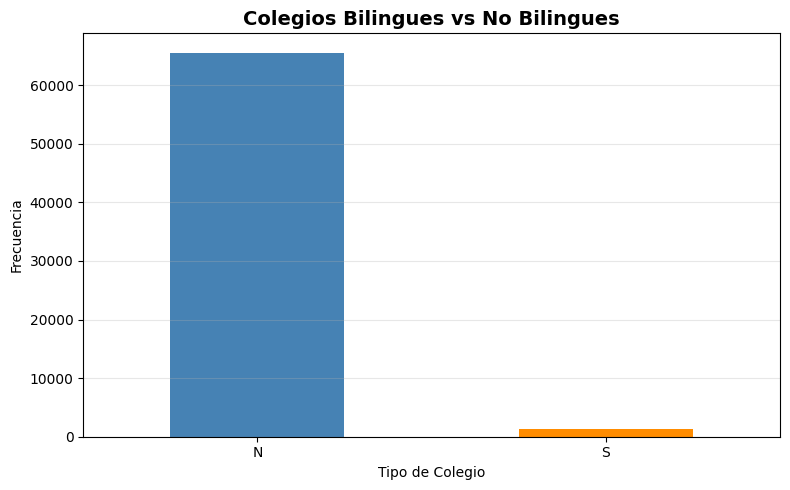

In [55]:
# Distribucion de la variable objetivo
print('Distribucion de cole_bilingue:')
print(df['cole_bilingue'].value_counts())
print('\nPorcentajes:')
print(df['cole_bilingue'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
df['cole_bilingue'].value_counts().plot(kind='bar', color=['steelblue', 'darkorange'])
plt.title('Colegios Bilingues vs No Bilingues', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Colegio')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [56]:
# Eliminar NaN en cole_bilingue
print(f"Antes: {len(df):,} registros")
print(f"NaN en cole_bilingue: {df['cole_bilingue'].isna().sum():,}")

df = df.dropna(subset=['cole_bilingue'])
print(f"Después: {len(df):,} registros")

# Normalizar nombres de columnas
df.columns = df.columns.str.lower()


Antes: 77,575 registros
NaN en cole_bilingue: 10,706
Después: 66,869 registros


In [57]:
# Comparar puntajes promedio por tipo de colegio
puntajes = ['punt_ingles', 'punt_matematicas', 'punt_lectura_critica', 'punt_global']

print('Puntajes promedio por tipo de colegio:')
comparacion = df.groupby('cole_bilingue')[puntajes].mean()
print(comparacion.round(1))

diff = comparacion.loc['S', 'punt_ingles'] - comparacion.loc['N', 'punt_ingles']
print(f'  Bilingues tienen {diff:.1f} puntos mas en ingles')


Puntajes promedio por tipo de colegio:
               punt_ingles  punt_matematicas  punt_lectura_critica  \
cole_bilingue                                                        
N                     48.1              49.0                  50.3   
S                     55.9              52.8                  53.8   

               punt_global  
cole_bilingue               
N                    244.3  
S                    265.3  
  Bilingues tienen 7.9 puntos mas en ingles


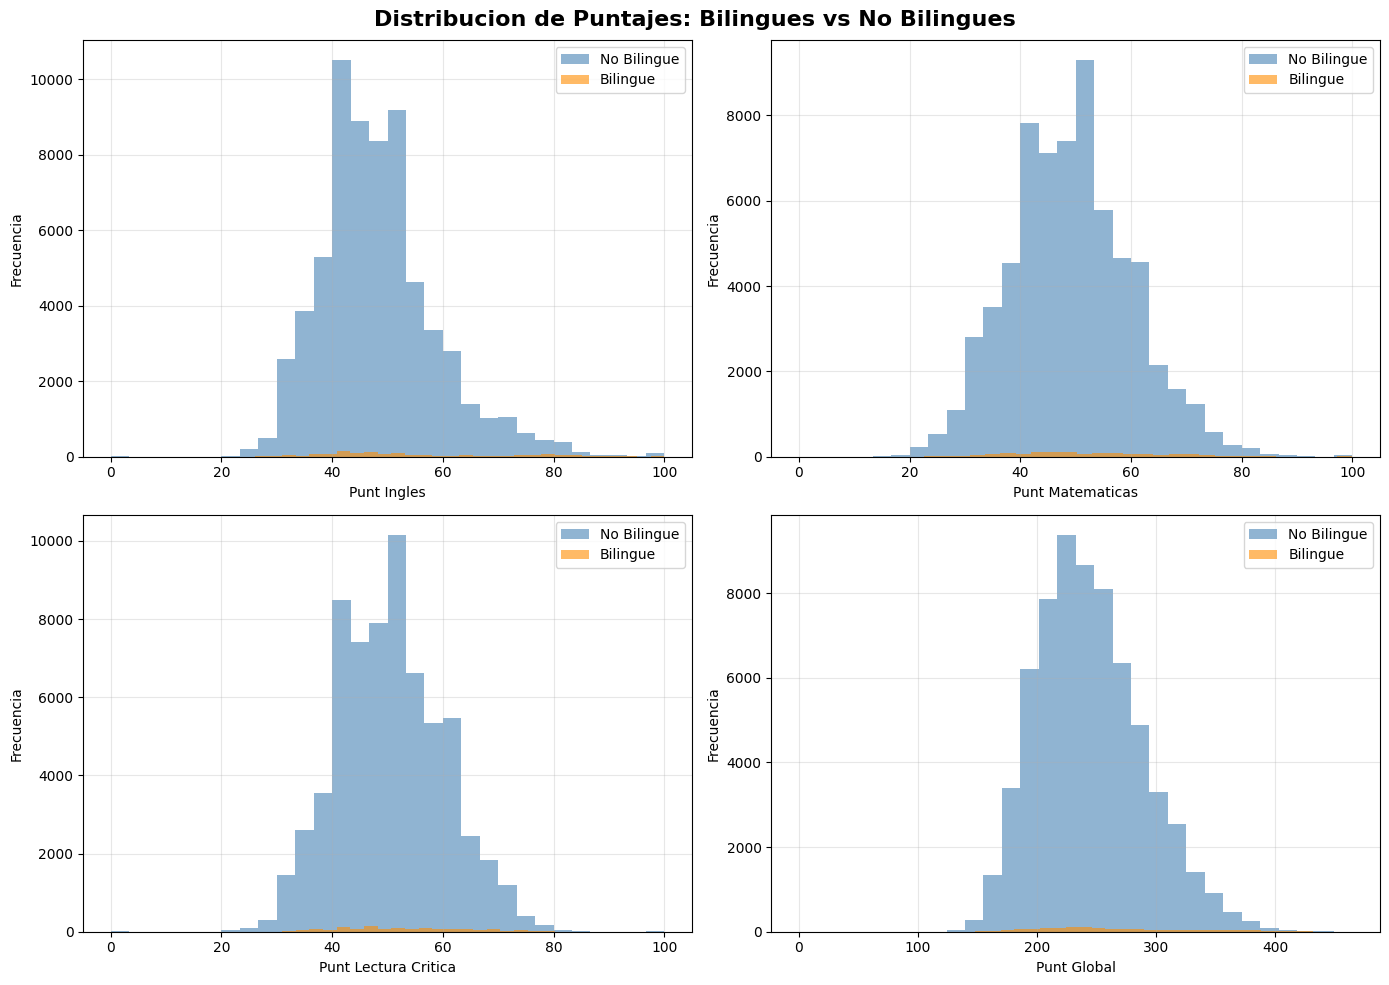

In [58]:
# Histogramas de puntajes por grupo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribucion de Puntajes: Bilingues vs No Bilingues', fontsize=16, fontweight='bold')

for idx, col in enumerate(puntajes):
    ax = axes[idx // 2, idx % 2]
    data_n = df[df['cole_bilingue'] == 'N'][col].dropna()
    data_s = df[df['cole_bilingue'] == 'S'][col].dropna()
    ax.hist(data_n, bins=30, alpha=0.6, label='No Bilingue', color='steelblue')
    ax.hist(data_s, bins=30, alpha=0.6, label='Bilingue', color='darkorange')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [59]:
# Features para el modelo
features_num = [
    'punt_lectura_critica', 'punt_matematicas', 'punt_sociales_ciudadanas',
    'punt_c_naturales', 'punt_ingles', 'punt_global', 'fami_estratovivienda'
]

features_cat = [
    'cole_naturaleza', 'cole_jornada', 'estu_genero',
    'fami_tieneinternet', 'fami_tienecomputador'
]

print(f"Features numéricas: {len(features_num)}")
print(f"Features categóricas: {len(features_cat)}")


Features numéricas: 7
Features categóricas: 5


In [60]:
# Preparar dataset
all_features = features_num + features_cat + ['cole_bilingue']
df_clean = df[all_features].copy()

print(f"Antes de limpieza: {len(df_clean):,}")
df_clean = df_clean.dropna()
print(f"Después de limpieza: {len(df_clean):,}")

# Convertir estrato a numérico
df_clean['fami_estratovivienda'] = df_clean['fami_estratovivienda'].str.extract(r'(\d+)', expand=False).astype(float)
df_clean = df_clean.dropna(subset=['fami_estratovivienda'])

print(f"\nFinal: {len(df_clean):,} registros")
print(f"Bilingües: {(df_clean['cole_bilingue']=='S').sum():,} ({(df_clean['cole_bilingue']=='S').sum()/len(df_clean)*100:.2f}%)")


Antes de limpieza: 66,869
Después de limpieza: 63,839

Final: 62,488 registros
Bilingües: 1,219 (1.95%)


In [61]:
# One-hot encoding
df_encoded = pd.get_dummies(df_clean, columns=features_cat, drop_first=True, dtype=float)

print(f"Columnas después de encoding: {df_encoded.shape[1]}")

# Listar nuevas columnas
nuevas = [col for col in df_encoded.columns if col not in features_num and col != 'cole_bilingue']
print(f"\nColumnas creadas por encoding: {len(nuevas)}")


Columnas después de encoding: 17

Columnas creadas por encoding: 9


In [62]:
# Preparar X e y
feature_cols = [col for col in df_encoded.columns 
                if col in features_num or any(cat in col for cat in features_cat)]

X = df_encoded[feature_cols].copy()
y = (df_encoded['cole_bilingue'] == 'S').astype(int)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Bilingües: {y.sum():,} ({y.sum()/len(y)*100:.2f}%)")
print(f"\nFeatures utilizadas: {len(feature_cols)}")


X shape: (62488, 16)
y shape: (62488,)
Bilingües: 1,219 (1.95%)

Features utilizadas: 16


In [63]:
from sklearn.model_selection import train_test_split

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} ({y_train.sum():,} bilingües, {y_train.sum()/len(y_train)*100:.2f}%)")
print(f"Test:  {X_test.shape[0]:,} ({y_test.sum():,} bilingües, {y_test.sum()/len(y_test)*100:.2f}%)")


Train: 49,990 (975 bilingües, 1.95%)
Test:  12,498 (244 bilingües, 1.95%)


In [64]:
from sklearn.utils import class_weight

# Pesos de clase para compensar el desbalance (~2% bilingues)
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}

print(f'Peso No Bilingue: {class_weight_dict[0]:.2f}')
print(f'Peso Bilingue:    {class_weight_dict[1]:.2f}')
print(f'Razon: {class_weight_dict[1]/class_weight_dict[0]:.1f}x mas peso a bilingues')


Peso No Bilingue: 0.51
Peso Bilingue:    25.64
Razon: 50.3x mas peso a bilingues


In [65]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping

print(f'TensorFlow: {tf.__version__}')


TensorFlow: 2.20.0


In [66]:
# Capa de normalizacion adaptada al set de entrenamiento
def build_norm_layer(X_arr):
    norm = tf.keras.layers.Normalization()
    norm.adapt(X_arr)
    return norm

X_train_arr = X_train.astype(float).values
X_test_arr = X_test.astype(float).values

norm_layer = build_norm_layer(X_train_arr)
print('Normalizacion creada')


Normalizacion creada


In [67]:
# Modelo baseline
model_baseline = Sequential([
    Input(shape=(X_train.shape[1],)),
    norm_layer,
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_baseline.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

model_baseline.summary()


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_2 (Normalization) │ (None, 16)             │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,234 (12.64 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 33 (136.00 B)

In [68]:
%%time
# Entrenamiento del modelo baseline
early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)

history_baseline = model_baseline.fit(
    X_train_arr, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print('Entrenamiento completado')


Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6669 - auc: 0.6910 - loss: 0.6260 - precision: 0.0332 - recall: 0.5575 - val_accuracy: 0.5323 - val_auc: 0.7207 - val_loss: 0.6545 - val_precision: 0.0273 - val_recall: 0.7429
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6559 - auc: 0.7301 - loss: 0.5966 - precision: 0.0369 - recall: 0.6463 - val_accuracy: 0.6521 - val_auc: 0.7370 - val_loss: 0.5939 - val_precision: 0.0310 - val_recall: 0.6229
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6384 - auc: 0.7417 - loss: 0.5796 - precision: 0.0359 - recall: 0.6612 - val_accuracy: 0.7013 - val_auc: 0.7620 - val_loss: 0.5665 - val_precision: 0.0369 - val_recall: 0.6400
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6933 - auc: 0.7472 - loss: 0.5724 - precision: 0.0397 - recall: 0.6187 - val_accuracy: 0.5152 - val_auc: 0.7603 - val_loss: 0.6019 - val_precision: 0.0296 - val_recall: 0.8400
Epoch 5/100
625/625 ━━━━━━━━

In [69]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predicciones sobre conjunto de prueba
y_pred_proba = model_baseline.predict(X_test_arr, verbose=0).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_proba)

print('Resultados - Modelo Baseline')
print(f'  Accuracy:  {acc:.4f}')
print(f'  Precision: {prec:.4f}')
print(f'  Recall:    {rec:.4f}')
print(f'  F1-Score:  {f1:.4f}')
print(f'  AUC-ROC:   {auc:.4f}')
print('\nMatriz de Confusion:')
print(confusion_matrix(y_test, y_pred))
print('\nReporte:')
print(classification_report(y_test, y_pred, target_names=['No Bilingue', 'Bilingue']))


Resultados - Modelo Baseline
  Accuracy:  0.6629
  Precision: 0.0414
  Recall:    0.7336
  F1-Score:  0.0783
  AUC-ROC:   0.7870

Matriz de Confusion:
[[8106 4148]
 [  65  179]]

Reporte:
              precision    recall  f1-score   support

 No Bilingue       0.99      0.66      0.79     12254
    Bilingue       0.04      0.73      0.08       244

    accuracy                           0.66     12498
   macro avg       0.52      0.70      0.44     12498
weighted avg       0.97      0.66      0.78     12498



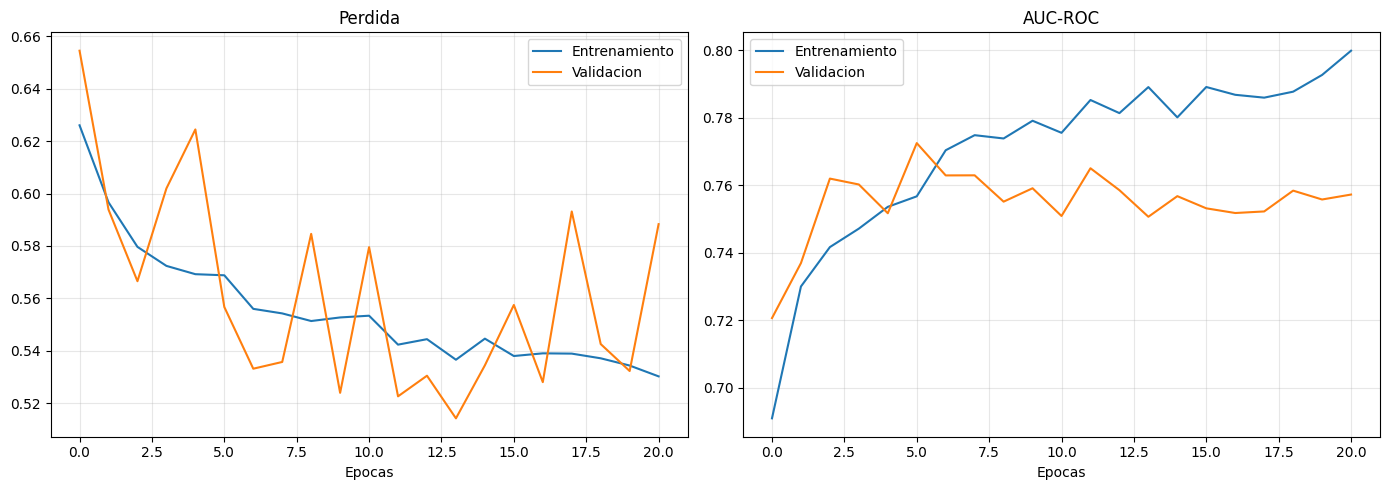

In [70]:
# Curvas de entrenamiento del baseline
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_baseline.history['loss'], label='Entrenamiento')
axes[0].plot(history_baseline.history['val_loss'], label='Validacion')
axes[0].set_title('Perdida')
axes[0].set_xlabel('Epocas')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_baseline.history['auc'], label='Entrenamiento')
axes[1].plot(history_baseline.history['val_auc'], label='Validacion')
axes[1].set_title('AUC-ROC')
axes[1].set_xlabel('Epocas')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [71]:
import mlflow
import mlflow.keras
import os

# Cerrar cualquier corrida activa antes de configurar el experimento
mlflow.end_run()

os.environ['MLFLOW_TRACKING_URI'] = 'file:./mlruns'
mlflow.set_experiment('Clasificacion_Colegios_Bilingues_CESAR')

print('MLflow configurado')
print(f'  Tracking URI: {mlflow.get_tracking_uri()}')


MLflow configurado
  Tracking URI: file:./mlruns


In [72]:
# Definir arquitecturas a probar
ARCHITECTURES = {
    'small': {'layers': [64, 32], 'dropouts': [0.3, 0.2]},
    'medium': {'layers': [128, 64, 32], 'dropouts': [0.4, 0.3, 0.2]},
    'large': {'layers': [256, 128, 64, 32], 'dropouts': [0.5, 0.4, 0.3, 0.2]},
    'deep': {'layers': [128, 64, 32, 16], 'dropouts': [0.4, 0.3, 0.2, 0.1]}
}

for name, config in ARCHITECTURES.items():
    print(f"{name:10s}: {config['layers']}")


small     : [64, 32]
medium    : [128, 64, 32]
large     : [256, 128, 64, 32]
deep      : [128, 64, 32, 16]


In [73]:
def build_model(arch, norm, n_feat, use_bn=False):
    """Construye un modelo secuencial con la arquitectura indicada."""
    layers = [Input(shape=(n_feat,)), norm]
    for units, dropout in zip(arch['layers'], arch['dropouts']):
        layers.append(Dense(units, activation='relu'))
        if use_bn:
            layers.append(BatchNormalization())
        layers.append(Dropout(dropout))
    layers.append(Dense(1, activation='sigmoid'))
    return Sequential(layers)

print('Funcion build_model definida')


Funcion build_model definida


In [74]:
print('Fase 1: Busqueda de arquitectura')

results_p1 = []

for arch_name, arch_cfg in ARCHITECTURES.items():
    print(f'  Probando {arch_name}...')
    with mlflow.start_run(run_name=f'arch_{arch_name}'):
        model = build_model(arch_cfg, norm_layer, X_train.shape[1], use_bn=False)
        model.compile(optimizer='adam', loss='binary_crossentropy',
                     metrics=['accuracy', keras.metrics.AUC(name='auc')])
        early = EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)
        history = model.fit(X_train_arr, y_train, epochs=100, batch_size=64,
                           validation_split=0.2, class_weight=class_weight_dict,
                           callbacks=[early], verbose=0)
        y_pred_proba = model.predict(X_test_arr, verbose=0).flatten()
        y_pred = (y_pred_proba > 0.5).astype(int)
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred)
        f1   = f1_score(y_test, y_pred)
        auc  = roc_auc_score(y_test, y_pred_proba)
        mlflow.log_param('architecture', arch_name)
        mlflow.log_param('layers', str(arch_cfg['layers']))
        mlflow.log_metric('accuracy', acc)
        mlflow.log_metric('precision', prec)
        mlflow.log_metric('recall', rec)
        mlflow.log_metric('f1_score', f1)
        mlflow.log_metric('auc_roc', auc)
        mlflow.keras.log_model(model, 'model')
        results_p1.append({'arch': arch_name, 'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc})
        print(f'    AUC: {auc:.4f}, Recall: {rec:.4f}')

df_p1 = pd.DataFrame(results_p1)
print(df_p1.sort_values('auc', ascending=False).to_string())


Fase 1: Busqueda de arquitectura
  Probando small...


2026/05/25 19:20:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 19:20:05 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


    AUC: 0.7831, Recall: 0.6434
  Probando medium...


2026/05/25 19:21:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 19:21:01 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


    AUC: 0.7917, Recall: 0.7377
  Probando large...


2026/05/25 19:22:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 19:22:13 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


    AUC: 0.7825, Recall: 0.7213
  Probando deep...


2026/05/25 19:22:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 19:22:48 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


    AUC: 0.7919, Recall: 0.7746
     arch       acc      prec       rec        f1       auc
3    deep  0.627460  0.039457  0.774590  0.075089  0.791920
1  medium  0.661146  0.041370  0.737705  0.078346  0.791689
0   small  0.718595  0.043769  0.643443  0.081963  0.783087
2   large  0.647304  0.038973  0.721311  0.073950  0.782540


In [75]:
best_arch = df_p1.loc[df_p1['auc'].idxmax(), 'arch']
print(f'Mejor arquitectura: {best_arch}')
print(f'  AUC: {df_p1.loc[df_p1["auc"].idxmax(), "auc"]:.4f}')


Mejor arquitectura: deep
  AUC: 0.7919


In [76]:
print('Fase 2: Comparacion con BatchNormalization')

results_p2 = []

for use_bn in [False, True]:
    print(f'  BatchNorm={use_bn}...')
    with mlflow.start_run(run_name=f'bn_{use_bn}_{best_arch}'):
        model = build_model(ARCHITECTURES[best_arch], norm_layer, X_train.shape[1], use_bn=use_bn)
        model.compile(optimizer='adam', loss='binary_crossentropy',
                     metrics=['accuracy', keras.metrics.AUC(name='auc')])
        early = EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)
        history = model.fit(X_train_arr, y_train, epochs=100, batch_size=64,
                           validation_split=0.2, class_weight=class_weight_dict,
                           callbacks=[early], verbose=0)
        y_pred_proba = model.predict(X_test_arr, verbose=0).flatten()
        y_pred = (y_pred_proba > 0.5).astype(int)
        auc = roc_auc_score(y_test, y_pred_proba)
        rec = recall_score(y_test, y_pred)
        mlflow.log_param('batchnorm', use_bn)
        mlflow.log_metric('auc_roc', auc)
        mlflow.keras.log_model(model, 'model')
        results_p2.append({'bn': use_bn, 'auc': auc, 'rec': rec})
        print(f'    AUC: {auc:.4f}')

df_p2 = pd.DataFrame(results_p2)
print(df_p2.sort_values('auc', ascending=False).to_string())


Fase 2: Comparacion con BatchNormalization
  BatchNorm=False...


2026/05/25 19:23:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 19:23:23 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


    AUC: 0.7755
  BatchNorm=True...


2026/05/25 19:24:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 19:24:08 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


    AUC: 0.7750
      bn       auc       rec
0  False  0.775497  0.643443
1   True  0.775041  0.766393


In [77]:
print('Fase 3: Ajuste de tasa de aprendizaje')

best_bn = df_p2.loc[df_p2['auc'].idxmax(), 'bn']
learning_rates = [0.0001, 0.0005, 0.001, 0.005]
results_p3 = []

for lr in learning_rates:
    print(f'  LR={lr}...')
    with mlflow.start_run(run_name=f'lr_{lr}_{best_arch}'):
        model = build_model(ARCHITECTURES[best_arch], norm_layer, X_train.shape[1], use_bn=best_bn)
        opt = keras.optimizers.Adam(learning_rate=lr)
        model.compile(optimizer=opt, loss='binary_crossentropy',
                     metrics=['accuracy', keras.metrics.AUC(name='auc')])
        early = EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)
        history = model.fit(X_train_arr, y_train, epochs=100, batch_size=64,
                           validation_split=0.2, class_weight=class_weight_dict,
                           callbacks=[early], verbose=0)
        y_pred_proba = model.predict(X_test_arr, verbose=0).flatten()
        auc = roc_auc_score(y_test, y_pred_proba)
        mlflow.log_param('learning_rate', lr)
        mlflow.log_metric('auc_roc', auc)
        mlflow.keras.log_model(model, 'model')
        results_p3.append({'lr': lr, 'auc': auc})
        print(f'    AUC: {auc:.4f}')

df_p3 = pd.DataFrame(results_p3)
print(df_p3.sort_values('auc', ascending=False).to_string())


Fase 3: Ajuste de tasa de aprendizaje
  LR=0.0001...


2026/05/25 19:25:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 19:25:44 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


    AUC: 0.7822
  LR=0.0005...


2026/05/25 19:26:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 19:26:47 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


    AUC: 0.7796
  LR=0.001...


2026/05/25 19:27:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 19:27:28 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


    AUC: 0.7852
  LR=0.005...


2026/05/25 19:28:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 19:28:15 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


    AUC: 0.7913
       lr       auc
3  0.0050  0.791297
2  0.0010  0.785245
0  0.0001  0.782172
1  0.0005  0.779566


In [78]:
best_lr  = df_p3.loc[df_p3['auc'].idxmax(), 'lr']
best_auc = df_p3.loc[df_p3['auc'].idxmax(), 'auc']

print('Mejor configuracion encontrada:')
print(f'  Arquitectura:     {best_arch} {ARCHITECTURES[best_arch]["layers"]}')
print(f'  BatchNorm:        {best_bn}')
print(f'  Tasa aprendizaje: {best_lr}')
print(f'  AUC-ROC:          {best_auc:.4f}')


Mejor configuracion encontrada:
  Arquitectura:     deep [128, 64, 32, 16]
  BatchNorm:        False
  Tasa aprendizaje: 0.005
  AUC-ROC:          0.7913


In [79]:
print('Entrenando modelo final...')

with mlflow.start_run(run_name='MODELO_FINAL'):
    final_model = build_model(ARCHITECTURES[best_arch], norm_layer, X_train.shape[1], use_bn=best_bn)
    opt = keras.optimizers.Adam(learning_rate=best_lr)
    final_model.compile(optimizer=opt, loss='binary_crossentropy',
                       metrics=['accuracy', keras.metrics.AUC(name='auc'),
                               keras.metrics.Precision(name='precision'),
                               keras.metrics.Recall(name='recall')])
    early = EarlyStopping(monitor='val_auc', mode='max', patience=20, restore_best_weights=True)
    history_final = final_model.fit(
        X_train_arr, y_train,
        epochs=150,
        batch_size=64,
        validation_split=0.2,
        class_weight=class_weight_dict,
        callbacks=[early],
        verbose=1
    )
    print('Modelo final entrenado')


Entrenando modelo final...
Epoch 1/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6308 - auc: 0.6676 - loss: 0.6517 - precision: 0.0311 - recall: 0.5788 - val_accuracy: 0.4186 - val_auc: 0.7360 - val_loss: 0.6817 - val_precision: 0.0262 - val_recall: 0.8914
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7097 - auc: 0.7177 - loss: 0.6104 - precision: 0.0383 - recall: 0.5600 - val_accuracy: 0.7444 - val_auc: 0.7120 - val_loss: 0.5524 - val_precision: 0.0352 - val_recall: 0.5143
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7658 - auc: 0.7258 - loss: 0.6072 - precision: 0.0442 - recall: 0.5188 - val_accuracy: 0.8790 - val_auc: 0.7152 - val_loss: 0.5247 - val_precision: 0.0588 - val_recall: 0.3943
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7386 - auc: 0.7202 - loss: 0.5987 - precision: 0.0411 - recall: 0.5400 - val_accuracy: 0.5111 - val_auc: 0.7605 - val_loss: 0.7146 - val_precision: 0.0295 - val_recall: 0.8457
E

In [80]:
# Evaluacion del modelo final
y_pred_proba_final = final_model.predict(X_test_arr, verbose=0).flatten()
y_pred_final = (y_pred_proba_final > 0.5).astype(int)

acc_f  = accuracy_score(y_test, y_pred_final)
prec_f = precision_score(y_test, y_pred_final, zero_division=0)
rec_f  = recall_score(y_test, y_pred_final)
f1_f   = f1_score(y_test, y_pred_final)
auc_f  = roc_auc_score(y_test, y_pred_proba_final)

print('Resultados - Modelo Final')
print(f'  Accuracy:  {acc_f:.4f} ({acc_f*100:.1f}%)')
print(f'  Precision: {prec_f:.4f} ({prec_f*100:.1f}%)')
print(f'  Recall:    {rec_f:.4f} ({rec_f*100:.1f}%)')
print(f'  F1-Score:  {f1_f:.4f}')
print(f'  AUC-ROC:   {auc_f:.4f}')

cm_f = confusion_matrix(y_test, y_pred_final)
print('\nMatriz de Confusion:')
print(f'  TN={cm_f[0,0]:5d}  FP={cm_f[0,1]:5d}')
print(f'  FN={cm_f[1,0]:5d}  TP={cm_f[1,1]:5d}')
print(f'\n{classification_report(y_test, y_pred_final, target_names=["No Bilingue", "Bilingue"])}')


Resultados - Modelo Final
  Accuracy:  0.5220 (52.2%)
  Precision: 0.0308 (3.1%)
  Recall:    0.7705 (77.0%)
  F1-Score:  0.0592
  AUC-ROC:   0.7566

Matriz de Confusion:
  TN= 6336  FP= 5918
  FN=   56  TP=  188

              precision    recall  f1-score   support

 No Bilingue       0.99      0.52      0.68     12254
    Bilingue       0.03      0.77      0.06       244

    accuracy                           0.52     12498
   macro avg       0.51      0.64      0.37     12498
weighted avg       0.97      0.52      0.67     12498



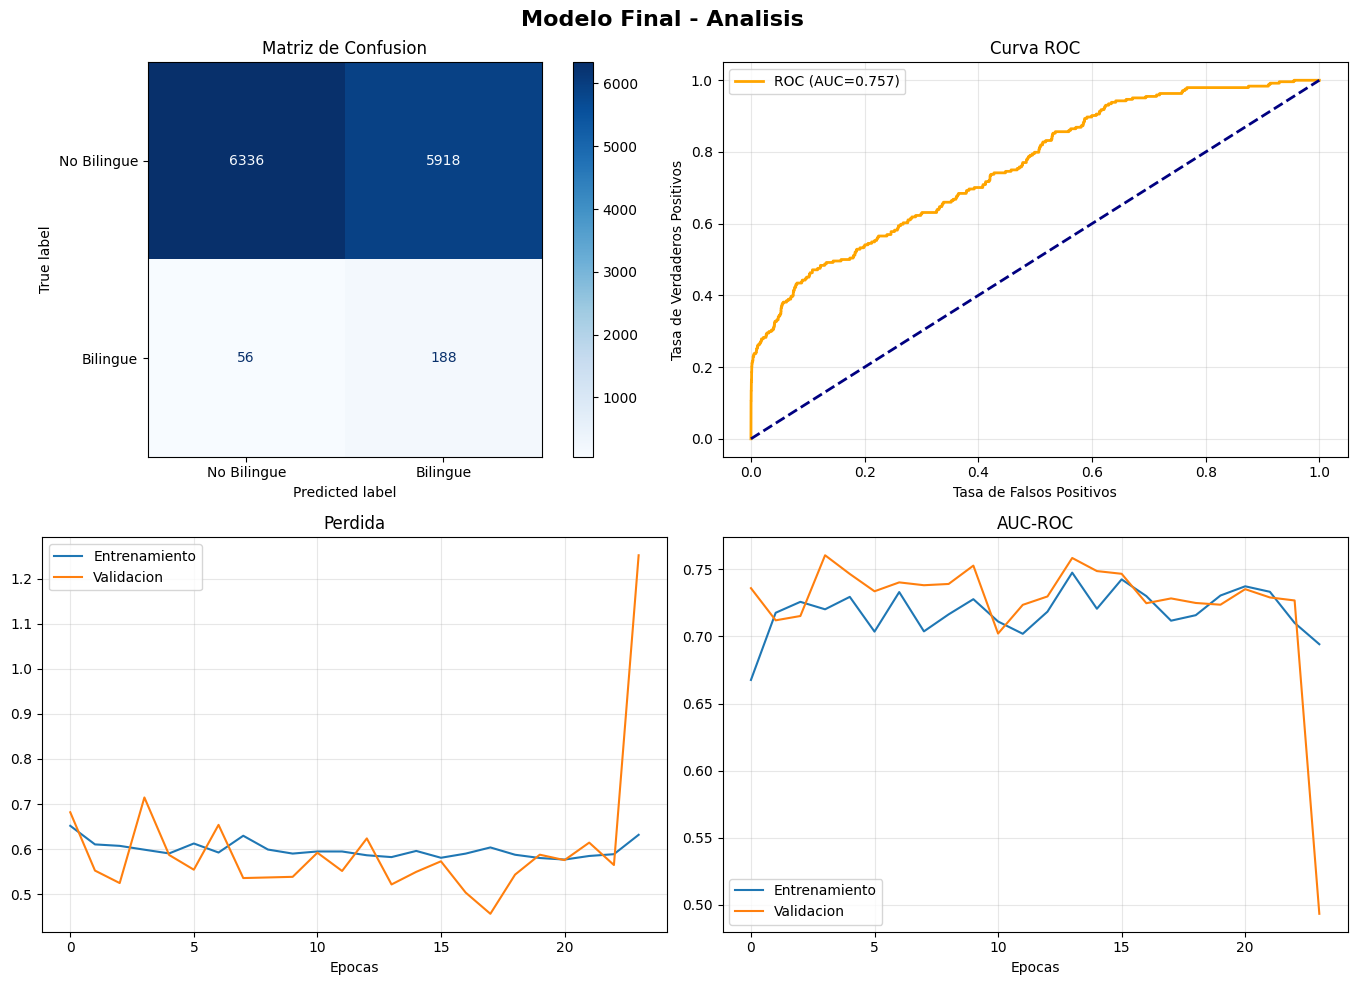

In [81]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Modelo Final - Analisis', fontsize=16, fontweight='bold')

# Matriz de confusion
ConfusionMatrixDisplay(cm_f, display_labels=['No Bilingue', 'Bilingue']).plot(ax=axes[0,0], cmap='Blues')
axes[0,0].set_title('Matriz de Confusion')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_final)
axes[0,1].plot(fpr, tpr, 'orange', lw=2, label=f'ROC (AUC={auc_f:.3f})')
axes[0,1].plot([0,1], [0,1], 'navy', lw=2, linestyle='--')
axes[0,1].set_title('Curva ROC')
axes[0,1].set_xlabel('Tasa de Falsos Positivos')
axes[0,1].set_ylabel('Tasa de Verdaderos Positivos')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Perdida de entrenamiento
axes[1,0].plot(history_final.history['loss'], label='Entrenamiento')
axes[1,0].plot(history_final.history['val_loss'], label='Validacion')
axes[1,0].set_title('Perdida')
axes[1,0].set_xlabel('Epocas')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# AUC de entrenamiento
axes[1,1].plot(history_final.history['auc'], label='Entrenamiento')
axes[1,1].plot(history_final.history['val_auc'], label='Validacion')
axes[1,1].set_title('AUC-ROC')
axes[1,1].set_xlabel('Epocas')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [82]:
import os

# Guardar modelo y lista de variables en carpeta modelos/
os.makedirs('../modelos', exist_ok=True)
final_model.save('../modelos/mejor_modelo_real.keras')
print('Modelo guardado: modelos/mejor_modelo_real.keras')

with open('../modelos/feature_names_real.txt', 'w') as f:
    for feat in feature_cols:
        f.write(f'{feat}\n')
print('Variables guardadas: modelos/feature_names_real.txt')

print('\nResumen:')
print(f'  Registros procesados: {len(df_clean):,}')
print(f'  Variables:            {len(feature_cols)}')
print(f'  Arquitectura:         {best_arch}')
print(f'  BatchNorm:            {best_bn}')
print(f'  Tasa aprendizaje:     {best_lr}')
print(f'  AUC-ROC final:        {auc_f:.4f}')
print(f'  Recall final:         {rec_f:.4f}')


Modelo guardado: modelos/mejor_modelo_real.keras
Variables guardadas: modelos/feature_names_real.txt

Resumen:
  Registros procesados: 62,488
  Variables:            16
  Arquitectura:         deep
  BatchNorm:            False
  Tasa aprendizaje:     0.005
  AUC-ROC final:        0.7566
  Recall final:         0.7705


## Ver experimentos en MLflow

Para explorar los resultados de las corridas:

```bash
mlflow ui
```

Abrir: http://localhost:5000


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12

fpr_q2, tpr_q2, _ = roc_curve(y_test, y_pred_proba_final)
auc_val = roc_auc_score(y_test, y_pred_proba_final)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr_q2, tpr_q2, color="#1a3a6b", lw=2.5, label=f"ROC (AUC = {auc_val:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--", label="Baseline aleatorio")

ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Curva ROC - Clasificacion Bilingue")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend(loc="lower right")
ax.grid(alpha=0.3, linestyle="--", linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("grafico_q2_roc.png", dpi=300, bbox_inches="tight", transparent=True, facecolor="white")
plt.show()
print(f"AUC-ROC: {auc_val:.4f}")
print("Guardado: grafico_q2_roc.png")